In [1]:
import numpy as np
import pandas as pd
import re
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.optimize import curve_fit
from scipy.stats import linregress

# Constants etc.

This is the stuff we adapt according to our files and what we want for our plots

In [2]:
# PATHS
data_dir = Path()
im_dir = Path('../../Imagens')
im_dir.mkdir(parents = True, exist_ok = True)

# FILES
file = 'Zona morta.xlsx'

# PRETTY COLORS
plot_colors = ['purple', 'xkcd:dodger blue', 'yellowgreen', 'darkorange', 'xkcd:dull red']
grid_color = 'lightgray'

# Load data

In [3]:
excel_data = pd.ExcelFile(data_dir / file)
sheets = excel_data.sheet_names
# print(sheets)

raw_sheets = [s for s in sheets if s.startswith('raw_Motor')] # only sheets with raw data

data = {} # dictionary to store data

pattern = re.compile(r'raw_Motor(\d)') # \d is for numbers
pattern2 = re.compile(r'w_(\S+)') # \S is characters, + is for a hole string instead of 1 character

for i, sheet in enumerate(raw_sheets):
    # find the number of the motor
    match = pattern.search(sheet)

    if match != None:
        motor_num = int(match.group(1))
        
        d_frame = pd.read_excel(file, sheet_name = sheet)
        cs = d_frame.columns
        d = d_frame.to_numpy().T
        V = d[0]
    
        for j, c in enumerate(cs):
            
            match2 = pattern2.search(c)
    
            if match2 != None:
                name = str(match2.group(1))
                w = d[j]
                key = f'Roda {motor_num} - modelo no {name}'
                data[key] = np.array([V, w])


print(data)

{'Roda 1 - modelo no ar': array([[  5. ,   4. ,   3. ,   2. ,   1. ,  -1. ,  -2. ,  -3. ,  -4. ,
         -5. ],
       [ 24.5,  19.5,  14.5,   9.3,   4.2,  -3.9,  -9.5, -14.7, -19.9,
        -24.7]]), 'Roda 1 - modelo no solo': array([[  5. ,   4. ,   3. ,   2. ,   1. ,  -1. ,  -2. ,  -3. ,  -4. ,
         -5. ],
       [ 22. ,  17. ,  12.4,   7.2,   2.1,  -1.5,  -6.7, -12.3, -17.5,
        -22.7]]), 'Roda 2 - modelo no ar': array([[  5. ,   4. ,   3. ,   2. ,   1. ,  -1. ,  -2. ,  -3. ,  -4. ,
         -5. ],
       [ 25.5,  20.2,  14.7,   9.9,   4. ,  -4.1,  -9.3, -14.4, -19.4,
        -24. ]]), 'Roda 2 - modelo no solo': array([[  5. ,   4. ,   3. ,   2. ,   1. ,  -1. ,  -2. ,  -3. ,  -4. ,
         -5. ],
       [ 22.7,  17.7,  12.3,   7. ,   1.7,  -1.7,  -6.8, -12.4, -17.5,
        -22.7]])}


# Analysis


 Roda 1 - modelo no ar
 - V > 0: V_0 = 0.165 V
 - V < 0: V_0 = -0.204 V

 Roda 1 - modelo no solo
 - V > 0: V_0 = 0.552 V
 - V < 0: V_0 = -0.718 V

 Roda 2 - modelo no ar
 - V > 0: V_0 = 0.212 V
 - V < 0: V_0 = -0.146 V

 Roda 2 - modelo no solo
 - V > 0: V_0 = 0.670 V
 - V < 0: V_0 = -0.681 V


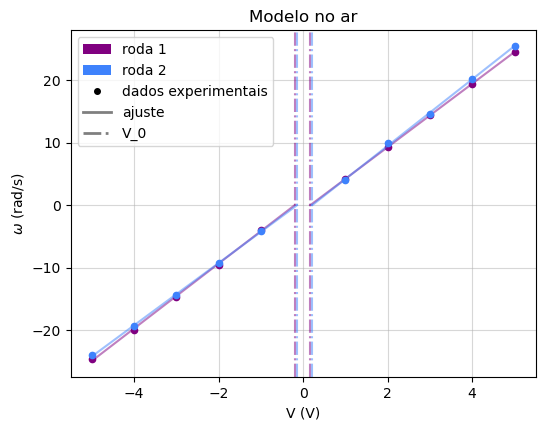

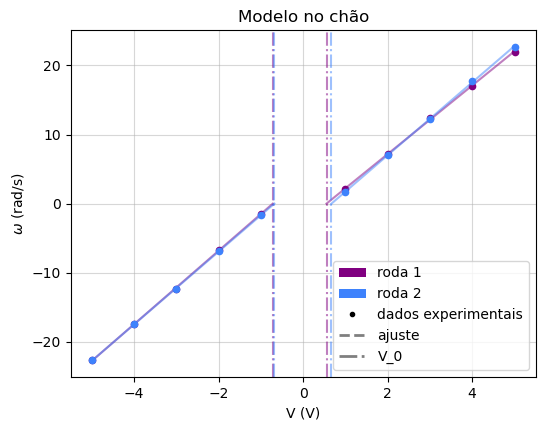

In [4]:
def linear(V, a, b):
    return a*V + b


motor_pattern = re.compile(r'(Roda \d)')


fig_ar, ax_ar = plt.subplots(figsize = (6, 4.5))
ax_ar.grid(grid_color, alpha = 0.5)
ax_ar.set_title('Modelo no ar')
ax_ar.set_xlabel('V (V)')
ax_ar.set_ylabel(r'$\omega$ (rad/s)')

motor_lines = [
    Patch(facecolor = plot_colors[k], edgecolor = 'none') for k in range(len(data)//2)
]
motor_labels = [f'roda {k + 1}' for k in range(len(data)//2)]
    
style_lines = [
    Line2D([0], [0], color = 'black', lw = 2, marker = '.', markersize = 8, linestyle = 'None'),
    Line2D([0], [0], color = 'black', lw = 2, linestyle = '-', alpha = 0.5),
    Line2D([0], [0], color = 'black', lw = 2, linestyle = '-.', alpha = 0.5)
]
style_labels = ['dados experimentais', 'ajuste', 'V_0']

ax_ar.legend(motor_lines + style_lines, motor_labels + style_labels)


fig_solo, ax_solo = plt.subplots(figsize = (6, 4.5))
ax_solo.grid(grid_color, alpha = 0.5)
ax_solo.set_title('Modelo no chão')
ax_solo.set_xlabel('V (V)')
ax_solo.set_ylabel(r'$\omega$ (rad/s)')

motor_lines = [
    Patch(facecolor = plot_colors[k], edgecolor = 'none') for k in range(len(data)//2)
]
motor_labels = [f'roda {k + 1}' for k in range(len(data)//2)]
    
style_lines = [
    Line2D([0], [0], color = 'black', lw = 2, marker = '.', linestyle = 'None'),
    Line2D([0], [0], color = 'black', lw = 2, linestyle = '--', alpha = 0.5),
    Line2D([0], [0], color = 'black', lw = 2, linestyle = '-.', alpha = 0.5)
]
style_labels = ['dados experimentais', 'ajuste', 'V_0']

ax_solo.legend(motor_lines + style_lines, motor_labels + style_labels)


for i, key in enumerate(data):
    print('\n', key)
    d = data[key]
    V = d[0]
    w = d[1]

    match = motor_pattern.search(key)
    label = match.group(1) if match else key
    
    if 'ar' in key:
        ax = ax_ar
    elif 'solo' in key:
        ax = ax_solo
    else:
        continue

    # mask to separate data from left and right side
    mask = V > 0
    ranges = ['V > 0', 'V < 0']

    for j, m in enumerate([mask, ~mask]):
        ax.plot(V[m], w[m], '.', markersize = 9, label = label, color = plot_colors[i//2])
        if m.sum() >= 2:
            pars, cov = curve_fit(linear, V[m], w[m])
            a, b = pars
            V_0 = -b/a
            print(f" - {ranges[j]}: V_0 = {V_0:.3f} V")

            ax.axvline(V_0, linestyle = '-.', color = plot_colors[i//2], alpha = 0.5)
            
            V_fit = np.linspace(min(V_0, V[m].min()), max(V_0, V[m].max()), 100)
            ax.plot(V_fit, linear(V_fit, *pars), '-', color = plot_colors[i//2], alpha = 0.5)

fig_ar.savefig(im_dir/f'zona_morta_modelo_no_ar', dpi = 200, bbox_inches = 'tight')
fig_solo.savefig(im_dir/f'zona_morta_modelo_no_chao', dpi = 200, bbox_inches = 'tight')


 Roda 1 - modelo no ar
 - V > 0: V_0 = 0.165 V
 - V < 0: V_0 = -0.204 V

 Roda 1 - modelo no solo
 - V > 0: V_0 = 0.552 V
 - V < 0: V_0 = -0.718 V

 Roda 2 - modelo no ar
 - V > 0: V_0 = 0.212 V
 - V < 0: V_0 = -0.146 V

 Roda 2 - modelo no solo
 - V > 0: V_0 = 0.670 V
 - V < 0: V_0 = -0.681 V


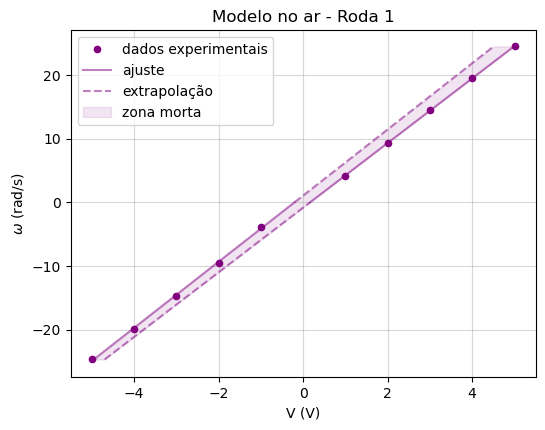

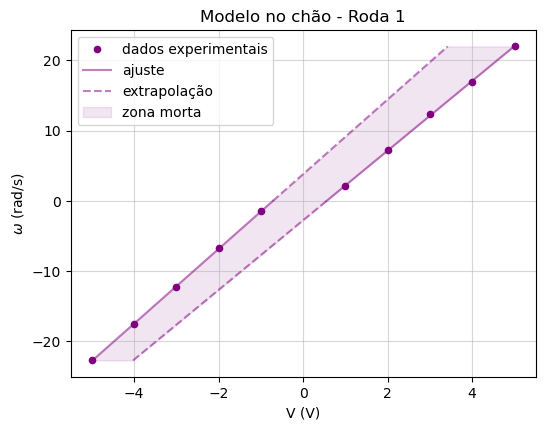

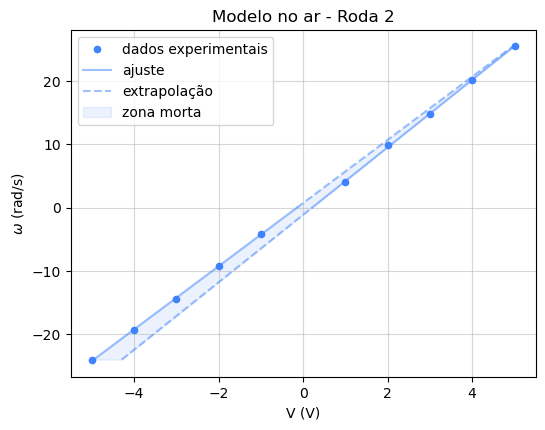

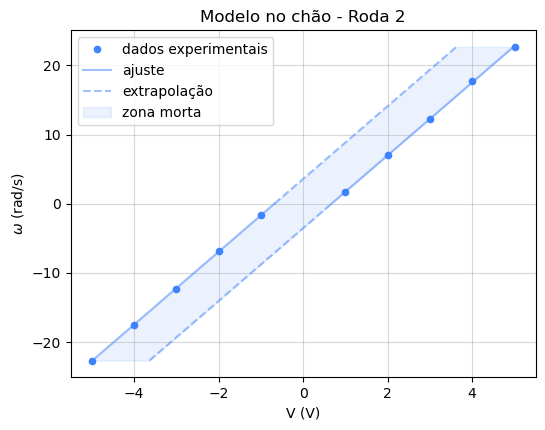

In [7]:
def linear(V, a, b):
    return a*V + b

def inv_linear(w, a, b):
    return (w - b) / a

motor_pattern = re.compile(r'(Roda \d)')

for i, key in enumerate(data):
    print('\n', key)
    d = data[key]
    V = d[0]
    w = d[1]
    match = motor_pattern.search(key)
    label = match.group(1) if match else key
    
    if 'ar' in key:
        modelo = 'Modelo no ar'
    elif 'solo' in key:
        modelo = 'Modelo no chão'
    else:
        continue
    
    fig, ax = plt.subplots(figsize = (6, 4.5))
    ax.grid(grid_color, alpha = 0.5)
    ax.set_title(f'{modelo} - {label}')
    ax.set_xlabel('V (V)')
    ax.set_ylabel(r'$\omega$ (rad/s)')

    # mask to separate data from left and right side
    mask = V > 0
    ranges = ['V > 0', 'V < 0']

    pars_list = [None, None]
    
    for j, m in enumerate([mask, ~mask]):
        ax.plot(V[m], w[m], '.', markersize = 9, color = plot_colors[i//2], label = 'dados experimentais' if j == 0 else None)
        
        if m.sum() >= 2:
            pars, cov = curve_fit(linear, V[m], w[m])
            a, b = pars
            V_0 = -b/a
            print(f" - {ranges[j]}: V_0 = {V_0:.3f} V")

            pars_list[j] = pars
            
            V_fit = np.linspace(min(V_0, V[m].min()), max(V_0, V[m].max()), 100)
            ax.plot(V_fit, linear(V_fit, *pars), '-', color = plot_colors[i//2], alpha = 0.5, label = 'ajuste' if j == 0 else None)
            
            # extrapolate to the most extreme (?) w on the other side
            idx = np.argmax(np.abs(w[~m]))
            w_target = w[~m][idx]
            V_target = (w_target - b) / a
            
            V_fit = np.linspace(min(V_0, V_target), max(V_0, V_target), 100)
            ax.plot(V_fit, linear(V_fit, *pars), '--', color = plot_colors[i//2], alpha = 0.5, label = 'extrapolação' if j == 0 else None)

        # paint the area between the two lines
        if pars_list[0] is not None and pars_list[1] is not None:
            w_fill = np.linspace(w.min(), w.max(), 200)
            V1 = inv_linear(w_fill, *pars_list[0])
            V2 = inv_linear(w_fill, *pars_list[1])
            ax.fill_betweenx(w_fill, V1, V2, color = plot_colors[i//2], alpha = 0.1, label = 'zona morta')

    ax.legend()
    fig.savefig(im_dir/f'zona_morta_{key}', dpi = 200, bbox_inches = 'tight')

In [6]:
excel_data.close() # close the excel file in case I want to edit it